# Actor-Critic for Defensive Chess

In this notebook, we will:
- Define what a defensive chess policy means in operational terms.
- Build a Gym-compatible chess environment around curated defensive scenarios.
- Use a masked actor-critic model so the policy only assigns probability to legal moves.
- Train the policy and evaluate whether it survives pressure more reliably than a random baseline.
- Show how the same design can be extended toward full chess, even though the notebook keeps training focused on tractable scenarios.

## 1. What “defensive chess” means

In this notebook, a defensive policy is rewarded for:
- avoiding immediate tactical disasters,
- preserving material when under pressure,
- improving king safety,
- reducing the opponent's attacking chances,
- and surviving bad positions longer.

That definition matters because reinforcement learning needs a **reward function**. If we only reward checkmate, the signal is too sparse. If we only reward safety, the agent can become passive. We therefore use a shaped reward that combines survival, material preservation, and king safety.

The notebook supports two environment modes:
- `scenarios`: curated defensive positions that train quickly and illustrate the algorithm clearly.
- `full_chess`: full legal move generation with the same interface, mainly to show how the design scales conceptually.

In [7]:
!pip install -q python-chess gymnasium torch matplotlib pandas numpy

In [8]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import chess
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from gymnasium import spaces
from IPython.display import display
from torch.distributions import Categorical

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

@dataclass
class NotebookConfig:
    environment_mode: str = "scenarios"  # "scenarios" or "full_chess"
    train_episodes: int = 350
    eval_episodes: int = 60
    gamma: float = 0.97
    learning_rate: float = 2e-3
    entropy_coef: float = 0.01
    value_coef: float = 0.5
    hidden_dim: int = 256
    max_steps_scenarios: int = 3
    max_steps_full_chess: int = 10
    survival_reward: float = 0.25
    check_penalty: float = 0.6
    king_danger_weight: float = 0.15
    attacked_piece_weight: float = 0.08
    material_weight: float = 0.20
    evaluation_print_games: int = 2

CONFIG = NotebookConfig()
ARTIFACT_DIR = Path("artifacts")
MODEL_PATH = ARTIFACT_DIR / "defensive_actor_critic.pt"
HISTORY_PATH = ARTIFACT_DIR / "defensive_actor_critic_history.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(CONFIG)
print(f"Using device: {DEVICE}")

NotebookConfig(environment_mode='scenarios', train_episodes=350, eval_episodes=60, gamma=0.97, learning_rate=0.002, entropy_coef=0.01, value_coef=0.5, hidden_dim=256, max_steps_scenarios=3, max_steps_full_chess=10, survival_reward=0.25, check_penalty=0.6, king_danger_weight=0.15, attacked_piece_weight=0.08, material_weight=0.2, evaluation_print_games=2)
Using device: cpu


## 2. Why actor-critic fits this problem

A pure policy-gradient method can learn from sparse and delayed outcomes, but its updates can be noisy. A value-based method can estimate long-term return, but it does not naturally represent a stochastic policy over legal chess moves.

Actor-critic combines both:
- The **actor** outputs a probability distribution over legal moves.
- The **critic** estimates how promising the current position is.
- The **advantage** measures whether the chosen move led to an outcome that was better or worse than the critic expected.

We use a small custom training loop instead of importing a full Stable-Baselines algorithm because chess needs **legal-action masking** over a very large discrete action space. The environment and rollout structure still stay close to a Stable-Baselines-style setup: Gym API, trajectories, returns, advantages, policy loss, value loss, and entropy regularization.

### Core update equations

For one trajectory, we compute discounted returns:

$$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots$$

The critic predicts a state value $V(s_t)$, and the advantage is:

$$A_t = G_t - V(s_t)$$

We then optimize:
- **policy loss**: makes good moves more likely,
- **value loss**: teaches the critic to predict returns,
- **entropy bonus**: prevents the actor from collapsing too early into one move everywhere.

That gives us a practical recipe:
1. Roll out a short game fragment.
2. Estimate returns and advantages.
3. Update actor and critic together.
4. Evaluate whether defensive metrics improve.

In [9]:
PIECE_VALUES = {
    chess.PAWN: 1.0,
    chess.KNIGHT: 3.0,
    chess.BISHOP: 3.25,
    chess.ROOK: 5.0,
    chess.QUEEN: 9.0,
    chess.KING: 0.0,
}

PROMOTIONS = [None, chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT]

def build_move_vocabulary() -> List[str]:
    moves = set()
    for from_square in chess.SQUARES:
        for to_square in chess.SQUARES:
            if from_square == to_square:
                continue
            moves.add(chess.Move(from_square, to_square).uci())
            from_rank = chess.square_rank(from_square)
            to_rank = chess.square_rank(to_square)
            if from_rank in (1, 6) and to_rank in (0, 7):
                for promotion in PROMOTIONS[1:]:
                    moves.add(chess.Move(from_square, to_square, promotion=promotion).uci())
    return sorted(moves)

MOVE_VOCAB = build_move_vocabulary()
MOVE_TO_INDEX = {uci: idx for idx, uci in enumerate(MOVE_VOCAB)}

def move_to_index(move: chess.Move) -> int:
    return MOVE_TO_INDEX[move.uci()]

def legal_action_mask(board: chess.Board) -> np.ndarray:
    mask = np.zeros(len(MOVE_VOCAB), dtype=np.float32)
    for move in board.legal_moves:
        mask[move_to_index(move)] = 1.0
    return mask

def board_material(board: chess.Board, color: chess.Color) -> float:
    total = 0.0
    for piece_type, value in PIECE_VALUES.items():
        total += len(board.pieces(piece_type, color)) * value
    return total

def count_attacked_pieces(board: chess.Board, color: chess.Color) -> int:
    attacked = 0
    for square, piece in board.piece_map().items():
        if piece.color == color and piece.piece_type != chess.KING:
            if board.is_attacked_by(not color, square):
                attacked += 1
    return attacked

def king_danger(board: chess.Board, color: chess.Color) -> int:
    king_square = board.king(color)
    if king_square is None:
        return 100
    danger = 0
    for square in chess.SquareSet(chess.BB_KING_ATTACKS[king_square] | chess.BB_SQUARES[king_square]):
        if board.is_attacked_by(not color, square):
            danger += 1
    return danger

def encode_board(board: chess.Board, perspective: chess.Color = chess.BLACK) -> np.ndarray:
    planes = np.zeros((12, 8, 8), dtype=np.float32)
    for square, piece in board.piece_map().items():
        row = 7 - chess.square_rank(square)
        col = chess.square_file(square)
        if perspective == chess.BLACK:
            row = 7 - row
            col = 7 - col
        color_offset = 0 if piece.color == perspective else 6
        plane_idx = color_offset + piece.piece_type - 1
        planes[plane_idx, row, col] = 1.0
    metadata = np.array([
        float(board.turn == perspective),
        float(board.has_kingside_castling_rights(perspective)),
        float(board.has_queenside_castling_rights(perspective)),
        float(board.has_kingside_castling_rights(not perspective)),
        float(board.has_queenside_castling_rights(not perspective)),
    ], dtype=np.float32)
    return np.concatenate([planes.reshape(-1), metadata])

OBSERVATION_SIZE = encode_board(chess.Board()).shape[0]
print(f"Observation size: {OBSERVATION_SIZE}")
print(f"Action vocabulary size: {len(MOVE_VOCAB)}")

Observation size: 773
Action vocabulary size: 5056


## 3. State, action, reward, and episode design

**State.** We encode the board as piece planes plus a few metadata features such as side to move and castling rights.

**Action.** The global action space contains every UCI move template we want the policy to know about. On each position, we build a **legal-action mask** so the actor can only sample legal moves.

**Reward.** Our reward is shaped for defense rather than pure winning:
- positive reward for surviving another move,
- positive reward for improving black's material balance,
- penalty when the black king stays under heavy pressure,
- penalty when black leaves pieces attacked,
- penalty for remaining in check,
- large penalty for being checkmated.

**Episode.** In scenario mode, each episode starts from a curated defensive setup and lasts only a few plies. That keeps training fast while still forcing the agent to react under pressure.

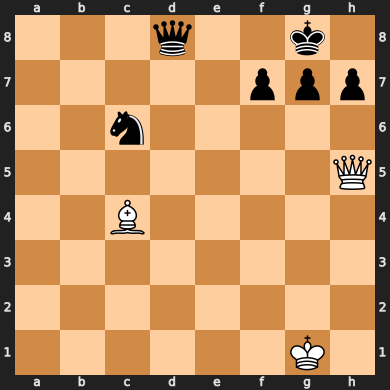

⭘ ⭘ ⭘ ♛ ⭘ ⭘ ♚ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ♟ ♟ ♟
⭘ ⭘ ♞ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♕
⭘ ⭘ ♗ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♔ ⭘
Scenario: Stop Qxf7 ideas
Legal moves: ['g8h8', 'g8f8', 'd8f8', 'd8e8', 'd8c8', 'd8b8', 'd8a8', 'd8e7', 'd8d7', 'd8c7', 'd8f6', 'd8d6'] ...


In [10]:
def board_from_pieces(pieces: List[Tuple[chess.Square, chess.Piece]], turn: chess.Color = chess.BLACK) -> chess.Board:
    board = chess.Board(None)
    board.turn = turn
    board.clear_stack()
    for square, piece in pieces:
        board.set_piece_at(square, piece)
    if not board.is_valid():
        raise ValueError(f"Invalid board: {board.fen()}")
    return board

TRAIN_SCENARIOS = [
    {
        "name": "Stop Qxf7 ideas",
        "board": board_from_pieces([
            (chess.G8, chess.Piece(chess.KING, chess.BLACK)),
            (chess.D8, chess.Piece(chess.QUEEN, chess.BLACK)),
            (chess.C6, chess.Piece(chess.KNIGHT, chess.BLACK)),
            (chess.F7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.G7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.H7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.G1, chess.Piece(chess.KING, chess.WHITE)),
            (chess.H5, chess.Piece(chess.QUEEN, chess.WHITE)),
            (chess.C4, chess.Piece(chess.BISHOP, chess.WHITE)),
        ]),
    },
    {
        "name": "Calm the kingside",
        "board": board_from_pieces([
            (chess.G8, chess.Piece(chess.KING, chess.BLACK)),
            (chess.C8, chess.Piece(chess.BISHOP, chess.BLACK)),
            (chess.F6, chess.Piece(chess.KNIGHT, chess.BLACK)),
            (chess.G7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.H6, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.G1, chess.Piece(chess.KING, chess.WHITE)),
            (chess.G4, chess.Piece(chess.QUEEN, chess.WHITE)),
            (chess.D3, chess.Piece(chess.BISHOP, chess.WHITE)),
        ]),
    },
    {
        "name": "Answer a central check",
        "board": board_from_pieces([
            (chess.G8, chess.Piece(chess.KING, chess.BLACK)),
            (chess.F8, chess.Piece(chess.ROOK, chess.BLACK)),
            (chess.G7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.H7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.G1, chess.Piece(chess.KING, chess.WHITE)),
            (chess.D5, chess.Piece(chess.QUEEN, chess.WHITE)),
            (chess.E1, chess.Piece(chess.ROOK, chess.WHITE)),
        ]),
    },
    {
        "name": "Defend the pinned knight",
        "board": board_from_pieces([
            (chess.G8, chess.Piece(chess.KING, chess.BLACK)),
            (chess.F6, chess.Piece(chess.KNIGHT, chess.BLACK)),
            (chess.D8, chess.Piece(chess.QUEEN, chess.BLACK)),
            (chess.G7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.H7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.G1, chess.Piece(chess.KING, chess.WHITE)),
            (chess.G5, chess.Piece(chess.BISHOP, chess.WHITE)),
            (chess.H5, chess.Piece(chess.QUEEN, chess.WHITE)),
        ]),
    },
]

EVAL_SCENARIOS = [
    {
        "name": "Reduce pressure on h7",
        "board": board_from_pieces([
            (chess.G8, chess.Piece(chess.KING, chess.BLACK)),
            (chess.D8, chess.Piece(chess.QUEEN, chess.BLACK)),
            (chess.F8, chess.Piece(chess.ROOK, chess.BLACK)),
            (chess.G7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.H7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.G1, chess.Piece(chess.KING, chess.WHITE)),
            (chess.H5, chess.Piece(chess.QUEEN, chess.WHITE)),
            (chess.C4, chess.Piece(chess.BISHOP, chess.WHITE)),
        ]),
    },
    {
        "name": "Stay safe after development",
        "board": board_from_pieces([
            (chess.G8, chess.Piece(chess.KING, chess.BLACK)),
            (chess.C8, chess.Piece(chess.BISHOP, chess.BLACK)),
            (chess.F6, chess.Piece(chess.KNIGHT, chess.BLACK)),
            (chess.D8, chess.Piece(chess.QUEEN, chess.BLACK)),
            (chess.G7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.H7, chess.Piece(chess.PAWN, chess.BLACK)),
            (chess.G1, chess.Piece(chess.KING, chess.WHITE)),
            (chess.C4, chess.Piece(chess.BISHOP, chess.WHITE)),
            (chess.G4, chess.Piece(chess.QUEEN, chess.WHITE)),
        ]),
    },
]

FULL_CHESS_STARTS = [
    ["e4"],
    ["d4"],
    ["Nf3"],
    ["c4"],
]

def aggressive_opponent_move(board: chess.Board, defender_color: chess.Color = chess.BLACK) -> chess.Move:
    legal_moves = list(board.legal_moves)
    best_move = legal_moves[0]
    best_score = -float("inf")
    defender_material_before = board_material(board, defender_color)
    defender_danger_before = king_danger(board, defender_color)
    for move in legal_moves:
        candidate = board.copy(stack=False)
        candidate.push(move)
        defender_material_after = board_material(candidate, defender_color)
        material_gain = defender_material_before - defender_material_after
        danger_gain = king_danger(candidate, defender_color) - defender_danger_before
        score = 0.0
        score += 6.0 if candidate.is_checkmate() else 0.0
        score += 1.5 if candidate.is_check() else 0.0
        score += 1.2 * material_gain
        score += 0.5 * danger_gain
        score += 0.1 * count_attacked_pieces(candidate, defender_color)
        if score > best_score:
            best_score = score
            best_move = move
    return best_move

def defensive_score(board: chess.Board, defender_color: chess.Color = chess.BLACK) -> Dict[str, float]:
    own_material = board_material(board, defender_color)
    opp_material = board_material(board, not defender_color)
    material_balance = own_material - opp_material
    attacked_pieces = count_attacked_pieces(board, defender_color)
    danger = king_danger(board, defender_color)
    still_in_check = float(board.is_check() and board.turn == defender_color)
    return {
        "material_balance": material_balance,
        "attacked_pieces": float(attacked_pieces),
        "king_danger": float(danger),
        "in_check": still_in_check,
    }

def reward_breakdown(before: chess.Board, after: chess.Board, config: NotebookConfig, defender_color: chess.Color = chess.BLACK) -> Dict[str, float]:
    before_score = defensive_score(before, defender_color)
    after_score = defensive_score(after, defender_color)
    parts = {
        "survival": config.survival_reward,
        "material": config.material_weight * (after_score["material_balance"] - before_score["material_balance"]),
        "king_safety": -config.king_danger_weight * (after_score["king_danger"] - before_score["king_danger"]),
        "attacked_pieces": -config.attacked_piece_weight * (after_score["attacked_pieces"] - before_score["attacked_pieces"]),
        "in_check": -config.check_penalty * after_score["in_check"],
        "checkmate": -8.0 if after.is_checkmate() else 0.0,
    }
    parts["total"] = sum(parts.values())
    return parts

sample_board = TRAIN_SCENARIOS[0]["board"]
display(sample_board)
print(sample_board.unicode())
print("Scenario:", TRAIN_SCENARIOS[0]["name"])
print("Legal moves:", [move.uci() for move in sample_board.legal_moves][:12], "...")

## 4. Building a defensive chess environment

The environment follows the Gym API:
- `reset()` returns the encoded board and metadata.
- `step(action)` applies a legal black move, lets the attacking side respond, and returns reward plus diagnostics.

A few design notes:
- The agent always plays the **defender** in this notebook: black.
- The white side uses a simple aggressive heuristic instead of a learned policy.
- The `info` dictionary exposes reward components and board state so we can debug why a move was good or bad.
- Illegal actions are never executed. If the actor proposes one, the environment replaces it with a random legal move and records that fallback in `info`.

This environment is intentionally small and transparent. In a larger project, you would likely split the environment, reward shaping, and training code into separate modules.

In [11]:
class DefensiveChessEnv(gym.Env):
    metadata = {"render_modes": ["unicode"]}

    def __init__(self, config: NotebookConfig, mode: str = "scenarios", split: str = "train"):
        super().__init__()
        self.config = config
        self.mode = mode
        self.split = split
        self.defender_color = chess.BLACK
        self.action_space = spaces.Discrete(len(MOVE_VOCAB))
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(OBSERVATION_SIZE,), dtype=np.float32)
        self.board = chess.Board()
        self.scenario_name = ""
        self.current_step = 0

    def _select_board(self) -> Tuple[chess.Board, str]:
        if self.mode == "scenarios":
            scenarios = TRAIN_SCENARIOS if self.split == "train" else EVAL_SCENARIOS
            choice = random.choice(scenarios)
            return choice["board"].copy(stack=False), choice["name"]
        if self.mode == "full_chess":
            opening = random.choice(FULL_CHESS_STARTS)
            board = chess.Board()
            for san in opening:
                board.push_san(san)
            return board, f"Full chess after {' '.join(opening)}"
        raise ValueError(f"Unknown mode: {self.mode}")

    def _get_obs(self) -> np.ndarray:
        return encode_board(self.board, perspective=self.defender_color)

    def reset(self, *, seed: int | None = None, options: dict | None = None):
        super().reset(seed=seed)
        self.board, self.scenario_name = self._select_board()
        self.current_step = 0
        info = {
            "scenario": self.scenario_name,
            "fen": self.board.fen(),
            "legal_mask": legal_action_mask(self.board),
            "board": self.board.copy(stack=False),
        }
        return self._get_obs(), info

    def step(self, action: int):
        if self.board.is_game_over():
            raise RuntimeError("Call reset() before stepping a finished episode.")

        self.current_step += 1
        before = self.board.copy(stack=False)
        proposed = chess.Move.from_uci(MOVE_VOCAB[action])
        legal_moves = list(self.board.legal_moves)
        used_illegal_fallback = False
        if proposed not in legal_moves:
            proposed = random.choice(legal_moves)
            used_illegal_fallback = True
        self.board.push(proposed)

        if not self.board.is_game_over():
            reply = aggressive_opponent_move(self.board, defender_color=self.defender_color)
            self.board.push(reply)
        else:
            reply = None

        breakdown = reward_breakdown(before, self.board, self.config, defender_color=self.defender_color)
        max_steps = self.config.max_steps_scenarios if self.mode == "scenarios" else self.config.max_steps_full_chess
        terminated = self.board.is_game_over()
        truncated = self.current_step >= max_steps
        info = {
            "scenario": self.scenario_name,
            "fen": self.board.fen(),
            "agent_move": proposed.uci(),
            "opponent_move": reply.uci() if reply else None,
            "illegal_fallback": used_illegal_fallback,
            "reward_parts": breakdown,
            "legal_mask": legal_action_mask(self.board) if not (terminated or truncated) else np.zeros(len(MOVE_VOCAB), dtype=np.float32),
            "board": self.board.copy(stack=False),
        }
        return self._get_obs(), breakdown["total"], terminated, truncated, info

    def render(self):
        print(self.board.unicode())

env = DefensiveChessEnv(CONFIG, mode=CONFIG.environment_mode, split="train")
obs, info = env.reset()
print("Scenario:", info["scenario"])
print("Observation shape:", obs.shape)
print("Legal moves available:", int(info["legal_mask"].sum()))
env.render()

Scenario: Answer a central check
Observation shape: (773,)
Legal moves available: 2
⭘ ⭘ ⭘ ⭘ ⭘ ♜ ♚ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ♕ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♖ ⭘ ♔ ⭘


## 5. Training the actor and critic

The model has two heads:
- an **actor head** that outputs logits for every move in the global action vocabulary,
- a **critic head** that predicts the expected return from the position.

Masking is the key chess-specific trick. We add a very large negative number to illegal move logits so their probability becomes effectively zero.

The training loop is intentionally simple:
1. Collect one trajectory from the environment.
2. Compute discounted returns.
3. Compute advantages as `returns - values`.
4. Update the policy and value function together.

This is enough to demonstrate how actor-critic works in a concrete defensive setting.

In [12]:
class MaskedActorCritic(nn.Module):
    def __init__(self, observation_size: int, action_size: int, hidden_dim: int = 256):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(observation_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.policy_head = nn.Linear(hidden_dim, action_size)
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, obs: torch.Tensor, mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        features = self.backbone(obs)
        logits = self.policy_head(features)
        masked_logits = logits.masked_fill(mask <= 0, -1e9)
        value = self.value_head(features).squeeze(-1)
        return masked_logits, value

def discounted_returns(rewards: List[float], gamma: float) -> torch.Tensor:
    returns = []
    running = 0.0
    for reward in reversed(rewards):
        running = reward + gamma * running
        returns.append(running)
    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32, device=DEVICE)

def rollout_episode(env: DefensiveChessEnv, model: MaskedActorCritic, greedy: bool = False):
    obs, info = env.reset()
    done = False
    trajectory = []
    total_reward = 0.0
    episode_boards = [info["board"] if "board" in info else env.board.copy(stack=False)]
    illegal_count = 0
    while not done:
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        mask_tensor = torch.tensor(info["legal_mask"], dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits, value = model(obs_tensor, mask_tensor)
        dist = Categorical(logits=logits)
        action = torch.argmax(logits, dim=-1) if greedy else dist.sample()
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        next_obs, reward, terminated, truncated, next_info = env.step(action.item())
        illegal_count += int(next_info["illegal_fallback"])
        trajectory.append({
            "obs": obs_tensor.squeeze(0),
            "mask": mask_tensor.squeeze(0),
            "action": action.squeeze(0),
            "log_prob": log_prob.squeeze(0),
            "entropy": entropy.squeeze(0),
            "value": value.squeeze(0),
            "reward": reward,
            "info": next_info,
        })
        total_reward += reward
        done = terminated or truncated
        obs, info = next_obs, next_info
        episode_boards.append(next_info["board"])
    return trajectory, total_reward, episode_boards, illegal_count

def save_training_artifacts(model: MaskedActorCritic, history: pd.DataFrame, config: NotebookConfig):
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": model.state_dict(),
        "observation_size": OBSERVATION_SIZE,
        "action_size": len(MOVE_VOCAB),
        "hidden_dim": config.hidden_dim,
        "environment_mode": config.environment_mode,
    }, MODEL_PATH)
    history.to_csv(HISTORY_PATH, index=False)

def load_training_artifacts(config: NotebookConfig):
    if not MODEL_PATH.exists() or not HISTORY_PATH.exists():
        return None, None
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    loaded_model = MaskedActorCritic(
        checkpoint["observation_size"],
        checkpoint["action_size"],
        hidden_dim=checkpoint.get("hidden_dim", config.hidden_dim),
    ).to(DEVICE)
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model.eval()
    loaded_history = pd.read_csv(HISTORY_PATH)
    return loaded_model, loaded_history

def train_actor_critic(config: NotebookConfig, save_artifacts: bool = True):
    env = DefensiveChessEnv(config, mode=config.environment_mode, split="train")
    model = MaskedActorCritic(OBSERVATION_SIZE, len(MOVE_VOCAB), hidden_dim=config.hidden_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    history = []
    for episode in range(1, config.train_episodes + 1):
        trajectory, total_reward, _, illegal_count = rollout_episode(env, model, greedy=False)
        returns = discounted_returns([step["reward"] for step in trajectory], config.gamma)
        log_probs = torch.stack([step["log_prob"] for step in trajectory])
        entropies = torch.stack([step["entropy"] for step in trajectory])
        values = torch.stack([step["value"] for step in trajectory])
        advantages = returns - values.detach()

        policy_loss = -(log_probs * advantages).mean()
        value_loss = F.mse_loss(values, returns)
        entropy_bonus = entropies.mean()
        loss = policy_loss + config.value_coef * value_loss - config.entropy_coef * entropy_bonus

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        history.append({
            "episode": episode,
            "reward": total_reward,
            "policy_loss": float(policy_loss.detach().cpu()),
            "value_loss": float(value_loss.detach().cpu()),
            "entropy": float(entropy_bonus.detach().cpu()),
            "illegal_fallbacks": illegal_count,
        })
    history_df = pd.DataFrame(history)
    if save_artifacts:
        save_training_artifacts(model, history_df, config)
    return model, history_df

model, history = train_actor_critic(CONFIG)
history.tail()

,episode,reward,policy_loss,value_loss,entropy,illegal_fallbacks
345,346,3.25,0.000529,0.017794,0.027704,0
346,347,2.26,0.003643,0.006019,0.137808,0
347,348,2.86,0.001464,0.022411,0.082741,0
348,349,2.26,-0.001353,0.000753,0.135544,0
349,350,3.25,-0.000108,0.002396,0.025611,0


## 6. Reward design tradeoffs

A defensive chess reward is useful only if it encourages the right behavior without creating bad shortcuts.

Important tradeoffs:
- **Too sparse**: if we only reward eventual wins or losses, the agent gets almost no learning signal in short episodes.
- **Too material-heavy**: the agent may save pieces but ignore king safety.
- **Too safety-heavy**: the agent may shuffle pieces passively and never challenge the attack.
- **Too much shaping**: the policy may optimize the reward formula rather than actual defensive quality.

The reward cell below inspects one position and compares candidate moves. This is a good habit in reinforcement learning: before training, verify that your reward assigns better scores to the behavior you actually want.

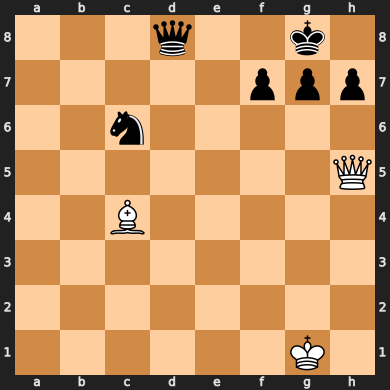

⭘ ⭘ ⭘ ♛ ⭘ ⭘ ♚ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ♟ ♟ ♟
⭘ ⭘ ♞ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♕
⭘ ⭘ ♗ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♔ ⭘


,move,survival,material,king_safety,attacked_pieces,in_check,checkmate,total
17,d8d4,0.25,0.0,-0.00,-0.00,-0.0,0.0,0.25
12,d8b6,0.25,0.0,-0.00,-0.08,-0.0,0.0,0.17
0,g8h8,0.25,-0.2,-0.15,-0.00,-0.6,0.0,-0.70
28,h7h6,0.25,-0.2,-0.30,0.08,-0.6,0.0,-0.77
4,d8c8,0.25,-0.2,-0.30,-0.00,-0.6,0.0,-0.85
5,d8b8,0.25,-0.2,-0.30,-0.00,-0.6,0.0,-0.85
2,d8f8,0.25,-0.2,-0.30,-0.00,-0.6,0.0,-0.85
10,d8f6,0.25,-0.2,-0.30,-0.00,-0.6,0.0,-0.85
7,d8e7,0.25,-0.2,-0.30,-0.00,-0.6,0.0,-0.85
9,d8c7,0.25,-0.2,-0.30,-0.00,-0.6,0.0,-0.85


In [13]:
def inspect_candidate_moves(board: chess.Board, candidate_uci_moves: List[str], config: NotebookConfig) -> pd.DataFrame:
    rows = []
    for uci in candidate_uci_moves:
        move = chess.Move.from_uci(uci)
        if move not in board.legal_moves:
            continue
        before = board.copy(stack=False)
        after = board.copy(stack=False)
        after.push(move)
        if not after.is_game_over():
            after.push(aggressive_opponent_move(after))
        parts = reward_breakdown(before, after, config)
        rows.append({"move": uci, **parts})
    return pd.DataFrame(rows).sort_values("total", ascending=False)

inspection_board = TRAIN_SCENARIOS[0]["board"].copy(stack=False)
display(inspection_board)
print(inspection_board.unicode())
inspect_candidate_moves(inspection_board, [move.uci() for move in inspection_board.legal_moves], CONFIG).head(10)

## 7. Evaluating whether the policy is actually defensive

A reward curve alone is not enough. We evaluate several defensive metrics:
- average episode reward,
- average survival length,
- final material balance,
- average number of attacked black pieces,
- average king danger,
- blunder rate, approximated here by large negative outcomes,
- illegal move rate, which should stay at zero because of masking.

We compare the trained policy to a random legal-move baseline on held-out scenarios.

In [14]:
def ensure_trained_artifacts(config: NotebookConfig):
    global model, history
    if "model" in globals() and "history" in globals():
        return model, history
    loaded_model, loaded_history = load_training_artifacts(config)
    if loaded_model is not None and loaded_history is not None:
        print(f"Loaded saved model from {MODEL_PATH} and history from {HISTORY_PATH}.")
        model, history = loaded_model, loaded_history
        return model, history
    print("No in-memory or saved training artifacts were found, so the notebook is training a fresh agent before evaluation.")
    model, history = train_actor_critic(config)
    return model, history

def evaluate_policy(model: MaskedActorCritic, config: NotebookConfig, greedy: bool = True, baseline: str = "trained"):
    env = DefensiveChessEnv(config, mode=config.environment_mode, split="eval")
    rows = []
    examples = []
    for episode in range(config.eval_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0.0
        last_info = info
        steps = 0
        boards = [env.board.copy(stack=False)]
        illegal_fallbacks = 0
        while not done:
            if baseline == "random":
                legal_indices = np.flatnonzero(info["legal_mask"] > 0)
                action = int(np.random.choice(legal_indices))
            else:
                obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                mask_tensor = torch.tensor(info["legal_mask"], dtype=torch.float32, device=DEVICE).unsqueeze(0)
                logits, _ = model(obs_tensor, mask_tensor)
                dist = Categorical(logits=logits)
                action = int(torch.argmax(logits, dim=-1).item()) if greedy else int(dist.sample().item())
            obs, reward, terminated, truncated, info = env.step(action)
            steps += 1
            total_reward += reward
            illegal_fallbacks += int(info["illegal_fallback"])
            done = terminated or truncated
            boards.append(info["board"])
            last_info = info
        score = defensive_score(last_info["board"], chess.BLACK)
        rows.append({
            "baseline": baseline,
            "reward": total_reward,
            "steps": steps,
            "material_balance": score["material_balance"],
            "attacked_pieces": score["attacked_pieces"],
            "king_danger": score["king_danger"],
            "blunder": float(total_reward < -2.0),
            "illegal_fallbacks": illegal_fallbacks,
            "scenario": last_info["scenario"],
        })
        if len(examples) < config.evaluation_print_games:
            examples.append({
                "baseline": baseline,
                "scenario": last_info["scenario"],
                "boards": boards,
                "reward": total_reward,
                "final_info": last_info,
            })
    return pd.DataFrame(rows), examples

model, history = ensure_trained_artifacts(CONFIG)
trained_eval, trained_examples = evaluate_policy(model, CONFIG, greedy=True, baseline="trained")
random_eval, random_examples = evaluate_policy(model, CONFIG, greedy=True, baseline="random")
comparison = pd.concat([trained_eval, random_eval], ignore_index=True)
comparison.groupby("baseline")[["reward", "steps", "material_balance", "attacked_pieces", "king_danger", "blunder", "illegal_fallbacks"]].mean().round(3)

,reward,steps,material_balance,attacked_pieces,king_danger,blunder,illegal_fallbacks
baseline,,,,,,,
random,-3.762,2.967,0.996,0.783,2.583,0.433,0.0
trained,-5.173,3.000,-0.617,0.867,2.867,0.433,0.0


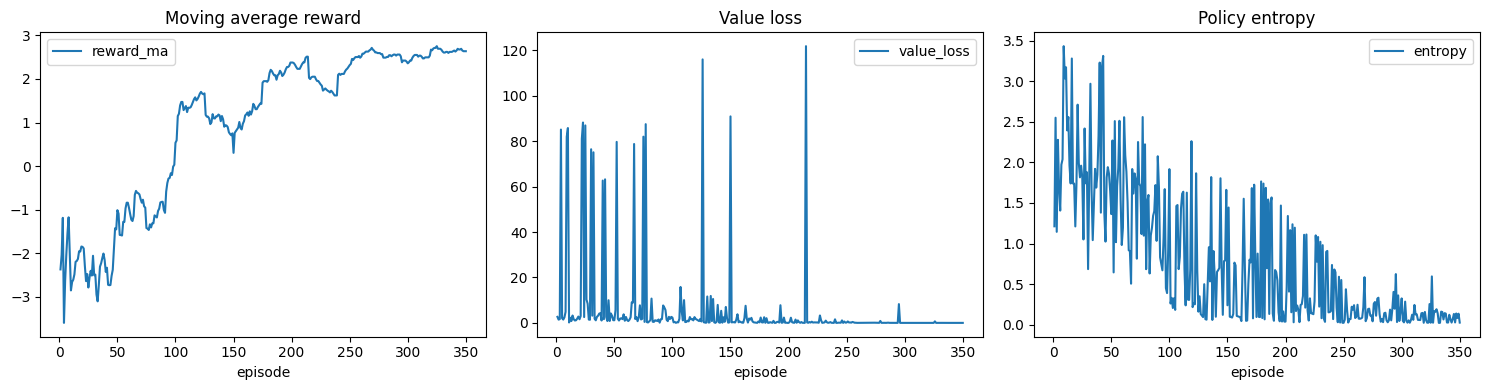

,reward,steps,material_balance,attacked_pieces,king_danger,blunder,illegal_fallbacks
baseline,,,,,,,
random,-3.762,2.967,0.996,0.783,2.583,0.433,0.0
trained,-5.173,3.000,-0.617,0.867,2.867,0.433,0.0



Example: trained | Reduce pressure on h7 | reward=-0.22
Initial board:
⭘ ⭘ ⭘ ♛ ⭘ ♜ ♚ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♕
⭘ ⭘ ♗ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♔ ⭘
Final board:
⭘ ⭘ ⭘ ♛ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♟ ♚
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ♗ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♔ ⭘
Final reward parts: {'survival': 0.25, 'material': -1.0, 'king_safety': -0.0, 'attacked_pieces': -0.0, 'in_check': -0.6, 'checkmate': 0.0, 'total': -1.35}

Example: random | Reduce pressure on h7 | reward=-1.02
Initial board:
⭘ ⭘ ⭘ ♛ ⭘ ♜ ♚ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♕
⭘ ⭘ ♗ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♔ ⭘
Final board:
⭘ ⭘ ⭘ ⭘ ⭘ ♜ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♟ ♚
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♗ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ♔ ⭘
Final reward parts: {'survival': 0.25, 'material': 1.8, 'king_safety': 0.15, 'attacked_pieces': 0.08, 'in_check': -0.6, 'checkmate': 0.0, 'total': 1.680000000000000

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
history["reward_ma"] = history["reward"].rolling(window=25, min_periods=1).mean()
history.plot(x="episode", y="reward_ma", ax=axes[0], title="Moving average reward")
history.plot(x="episode", y="value_loss", ax=axes[1], title="Value loss")
history.plot(x="episode", y="entropy", ax=axes[2], title="Policy entropy")
plt.tight_layout()
plt.show()

summary = comparison.groupby("baseline")[["reward", "steps", "material_balance", "attacked_pieces", "king_danger", "blunder", "illegal_fallbacks"]].mean().round(3)
display(summary)

for example in trained_examples[:1] + random_examples[:1]:
    print(f"\nExample: {example['baseline']} | {example['scenario']} | reward={example['reward']:.2f}")
    print("Initial board:")
    print(example["boards"][0].unicode())
    print("Final board:")
    print(example["boards"][-1].unicode())
    print("Final reward parts:", example["final_info"]["reward_parts"])


## 8. Interpreting the results

If training worked, the trained agent should usually:
- achieve higher average reward than the random baseline,
- leave fewer black pieces hanging,
- keep king danger lower,
- and produce fewer strongly negative episodes.

Do not expect grandmaster-level behavior. The point of this notebook is that the **actor-critic pipeline is visible**: observations, legal-action masking, reward shaping, trajectory collection, returns, advantages, and evaluation.

## 9. From simplified scenarios to full chess

The same actor-critic structure can scale toward full chess, but several things get harder:
- the action space becomes far more diverse across long games,
- sparse long-term rewards dominate,
- one heuristic attacker is no longer enough,
- and the policy needs a much richer observation model.

A practical roadmap is:
1. Keep the same Gym-compatible environment shape and legal-action masking.
2. Increase observation richness, such as piece-square tables, repetition counters, or learned board encoders.
3. Use larger scenario libraries or engine-generated defensive puzzles.
4. Introduce curriculum learning from tactical defense to full middlegame survival.
5. Replace this simple actor-critic loop with a more stable variant such as A2C or PPO when optimization stability becomes the bottleneck.

You can try the same environment in `full_chess` mode by changing `CONFIG.environment_mode`, but convergence there requires more compute, richer rewards, and stronger opponents than this notebook is designed to use.